In [1]:
import time
import plotly.express as px
import pandas as pd

from wildfire_sim import run_sim as serial_run_sim
from wildfire_sim_mult import run_sim as parallel_run_sim
from wildfire_sim_dask import run_sim as dask_run_sim

For this exercise, we simulate the spread of a wildfire using a Monte Carlo approach. The below implementation is used for the simulation which is adapted from the code provided within this assignment. 

```python
import numpy as np
import matplotlib.pyplot as plt
import random

# Constants
GRID_SIZE = 800  # 800x800 forest grid
FIRE_SPREAD_PROB = 0.3  # Probability that fire spreads to a neighboring tree
BURN_TIME = 3  # Time before a tree turns into ash
DAYS = 60  # Maximum simulation time

# State definitions
EMPTY = 0    # No tree
TREE = 1     # Healthy tree 
BURNING = 2  # Burning tree 
ASH = 3      # Burned tree 

def initialize_forest():
    """Creates a forest grid with all trees and ignites one random tree."""
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)  # All trees
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)  # Tracks how long a tree burns
    
    # Ignite a random tree
    x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1  # Fire starts burning
    
    return forest, burn_time

def get_neighbors(x, y):
    """Returns the neighboring coordinates of a cell in the grid."""
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Up, Down, Left, Right
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors

def simulate_wildfire():
    """Simulates wildfire spread over time."""
    forest, burn_time = initialize_forest()
    
    fire_spread = []  # Track number of burning trees each day
    
    for day in range(DAYS):
        new_forest = forest.copy()
        
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1  # Increase burn time
                    
                    # If burn time exceeds threshold, turn to ash
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    
                    # Spread fire to neighbors
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        
        if np.sum(forest == BURNING) == 0:  # Stop if no more fire
            break
    
    return fire_spread

def run_sim(num_runs=10):
    """Runs multiple wildfire simulations and averages the results."""
    all_spreads = []
    
    for i in range(num_runs):
        spread = simulate_wildfire()
        all_spreads.append(spread)
    
    # Pad results to the same length and average
    max_length = max(len(spread) for spread in all_spreads)
    padded_spreads = [spread + [0] * (max_length - len(spread)) for spread in all_spreads]
    
    average_spread = np.mean(padded_spreads, axis=0)
    
    return average_spread


if __name__ == "__main__":

    avg_fire_spread_over_time = run_sim(num_runs=10)

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(avg_fire_spread_over_time)), avg_fire_spread_over_time, label="Burning Trees")
    plt.xlabel("Days")
    plt.ylabel("Number of Burning Trees")
    plt.title("Wildfire Spread Over Time")
    plt.legend()
    plt.show()
```

## Task 1.1 Parallelisation with Multiprocessing
We begin by modifying the wildfire simulation to run independent simulations in parallel using the multiprocessing module.

```python
def simulate_wildfire(sim_id):

    forest, burn_time = initialize_forest()
    
    fire_spread = []  # Track number of burning trees each day
    
    for day in range(DAYS):
        new_forest = forest.copy()
        
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1  # Increase burn time
                    
                    # If burn time exceeds threshold, turn to ash
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    
                    # Spread fire to neighbors
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        
        if np.sum(forest == BURNING) == 0:  # Stop if no more fire
            break
        
    
    return fire_spread



def run_sim(num_simulations=10, num_workers=1):

    num_workers = num_workers 

    # Create a pool of workers and run simulations in parallel
    with multiprocessing.Pool(processes=num_workers) as pool:
        results = pool.map(simulate_wildfire, range(num_simulations))

    # Average the results across simulations
    max_days = max(len(result) for result in results)
    avg_fire_spread = np.zeros(max_days)

    for d in range(max_days):
        day_values = [result[d] for result in results if d < len(result)]
        avg_fire_spread[d] = np.mean(day_values)


    return avg_fire_spread
```

All other functions from the provided code remain unchanged

The output of the multiprocessing version is as follows
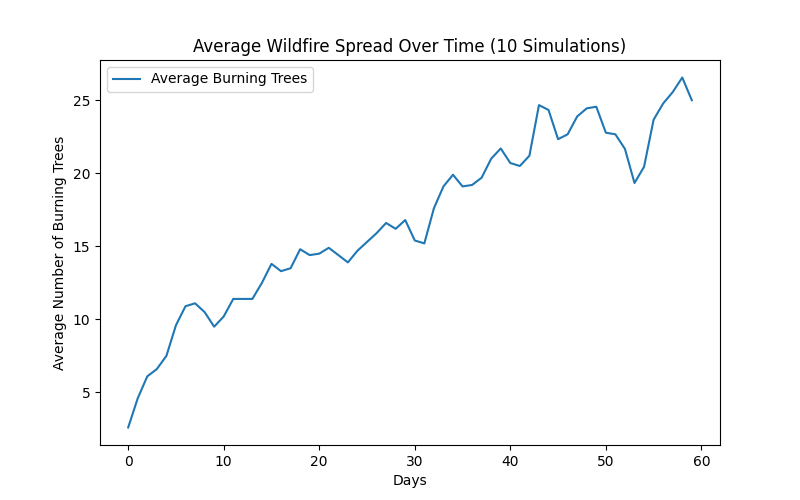

## Task 1.2 Parallelisation with Dask
We further optimise the wildfire simulation using Dask.

```python
@dask.delayed
def simulate_wildfire_delayed(sim_id):
    """Simulates wildfire spread and returns a fixed-length array for Dask Array conversion."""
    forest, burn_time = initialize_forest()
    fire_spread = []
    
    for day in range(DAYS):
        new_forest = forest.copy()
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        if np.sum(forest == BURNING) == 0:
            break
            
    # Pad results with 0s to ensure consistent shape for Dask Array 
    padded_results = fire_spread + [0] * (DAYS - len(fire_spread))
    return np.array(padded_results)

def run_sim(num_simulations=10, num_workers=1):
    """Executes simulations using Dask Distributed and aggregates results."""
    # 1. Initialize Dask Client for Dashboard access 
    client = Client(processes=False, n_workers=num_workers) 
    print(f"Dask Dashboard is active at: {client.dashboard_link}")

    # 2. Create Delayed objects (Task Graph) 
    delayed_tasks = [simulate_wildfire_delayed(i) for i in range(num_simulations)]

    # 3. Convert results into a Dask Array for efficient aggregation 
    # We create a Dask array from the list of delayed objects
    dask_arrays = [da.from_delayed(task, shape=(DAYS,), dtype=int) for task in delayed_tasks]
    stacked_sims = da.stack(dask_arrays, axis=0)

    # 4. Compute the average across the simulation axis (axis 0)
    mean_spread_task = stacked_sims.mean(axis=0)

    # 5. Execute calculations
    print("Executing simulations in parallel via Dask...")
    avg_fire_spread = mean_spread_task.compute()
    
    client.close()
    return avg_fire_spread
```

All other functions from the provided code remain unchanged

The output of the dask optimised version is as follows:

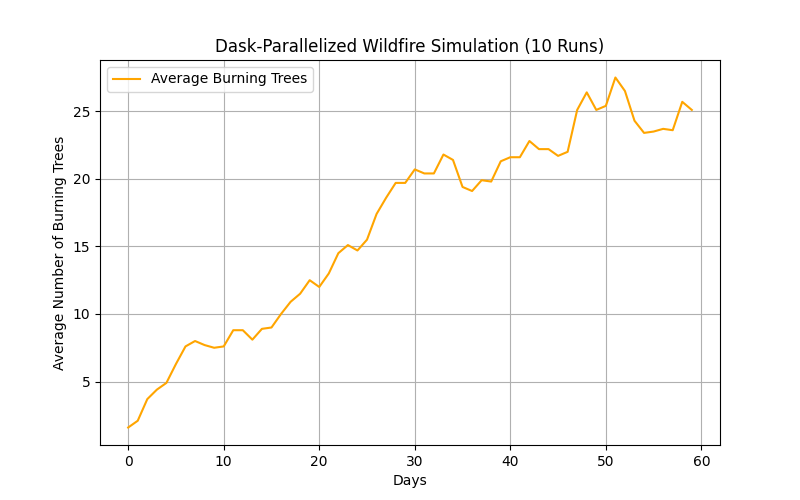

Dask Dashboard output

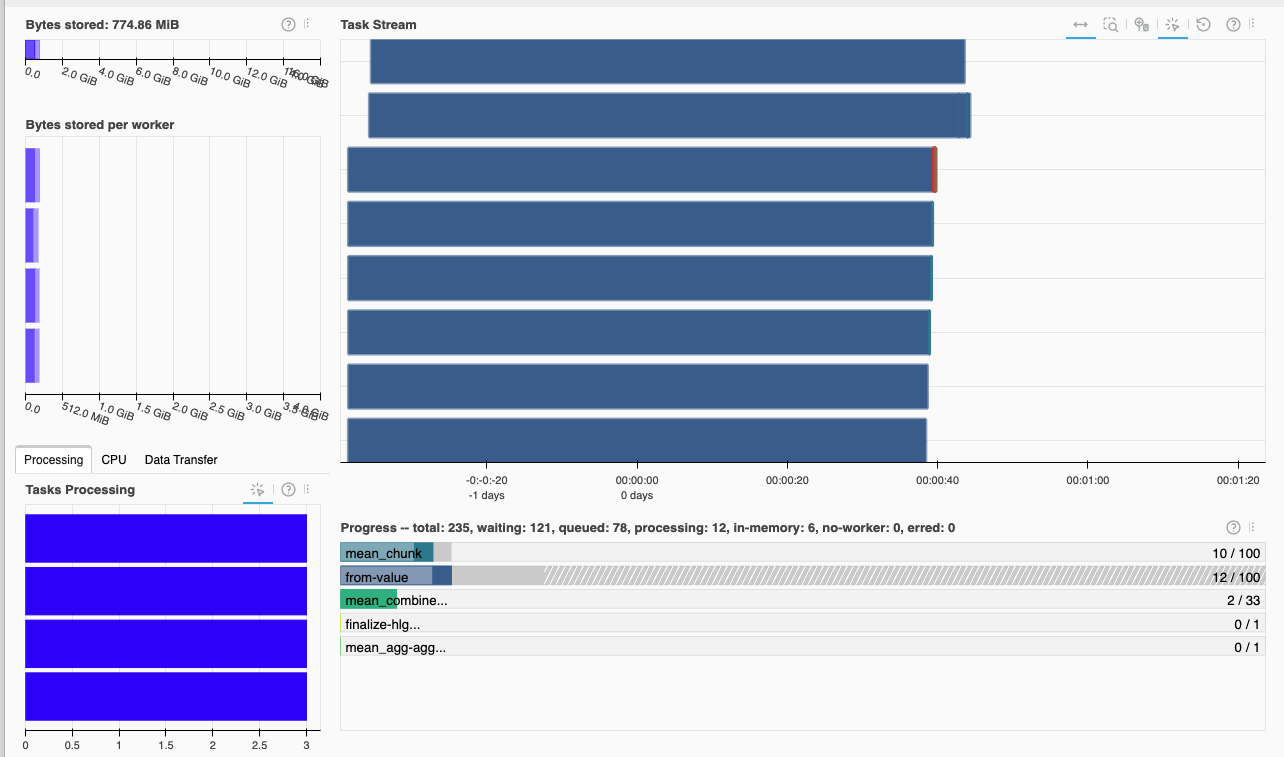

## Task 1.3 Performance Comparison.

We measure the execution time each implementation with a range of implementations to investigate how performance scales at different loads.

In [2]:
def wildfire_benchmark():
    sim_counts = [1, 5, 10, 20]
    worker_counts = [2, 4, 8]
    results = []

    for n_sims in sim_counts:
        # 1. Serial Benchmark
        print(f"Benchmarking Serial (n={n_sims})...")
        start = time.time()
        serial_run_sim(num_runs=n_sims)
        results.append({
            "Simulations": n_sims, 
            "Implementation": "Serial", 
            "Workers": 1, 
            "Time": time.time() - start
        })

        for workers in worker_counts:
            # 2. Multiprocessing Scaling
            print(f"Benchmarking Multiprocessing (n={n_sims}, w={workers})...")
            start = time.time()
            parallel_run_sim(num_simulations=n_sims, num_workers=workers)
            results.append({
                "Simulations": n_sims, 
                "Implementation": f"Multiprocessing ({workers} Workers)", 
                "Workers": workers, 
                "Time": time.time() - start
            })

            # 3. Dask Scaling
            print(f"Benchmarking Dask (n={n_sims}, w={workers})...")
            start = time.time()
            dask_run_sim(num_simulations=n_sims, num_workers=workers)
            results.append({
                "Simulations": n_sims, 
                "Implementation": f"Dask ({workers} Workers)", 
                "Workers": workers, 
                "Time": time.time() - start
            })

    return pd.DataFrame(results)

Benchmarking Serial (n=1)...
Benchmarking Multiprocessing (n=1, w=2)...
Benchmarking Dask (n=1, w=2)...
Dask Dashboard is active at: http://100.123.111.32:8787/status
Executing simulations in parallel via Dask...
Benchmarking Multiprocessing (n=1, w=4)...
Benchmarking Dask (n=1, w=4)...
Dask Dashboard is active at: http://100.123.111.32:8787/status
Executing simulations in parallel via Dask...
Benchmarking Multiprocessing (n=1, w=8)...
Benchmarking Dask (n=1, w=8)...
Dask Dashboard is active at: http://100.123.111.32:8787/status
Executing simulations in parallel via Dask...
Benchmarking Serial (n=5)...
Benchmarking Multiprocessing (n=5, w=2)...
Benchmarking Dask (n=5, w=2)...
Dask Dashboard is active at: http://100.123.111.32:8787/status
Executing simulations in parallel via Dask...
Benchmarking Multiprocessing (n=5, w=4)...
Benchmarking Dask (n=5, w=4)...
Dask Dashboard is active at: http://100.123.111.32:8787/status
Executing simulations in parallel via Dask...
Benchmarking Multiproc

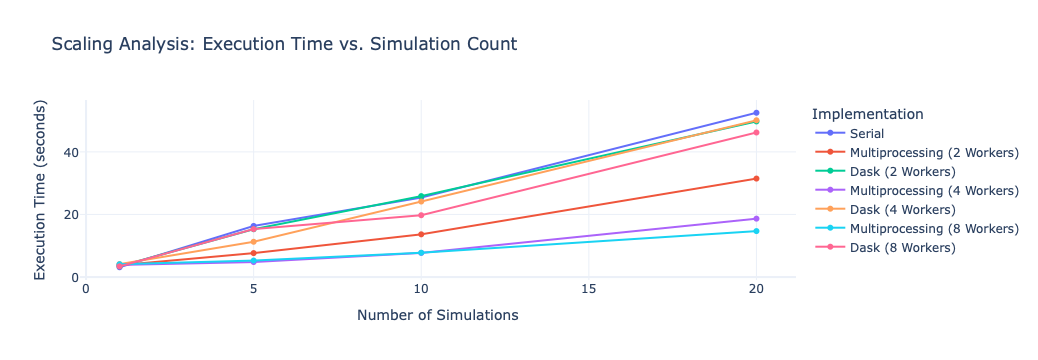

In [3]:
# Run benchmark
df_scaling = wildfire_benchmark()

# Create Line Graph
fig = px.line(
    df_scaling, 
    x="Simulations", 
    y="Time", 
    color="Implementation",
    markers=True,
    title="Scaling Analysis: Execution Time vs. Simulation Count",
    labels={"Time": "Execution Time (seconds)", "Simulations": "Number of Simulations"}
)

fig.update_layout(template="plotly_white", hovermode="x unified")
fig.show()

In [7]:
print(df_scaling.sort_values(by="Simulations", ascending=True))

    Simulations               Implementation  Workers       Time
0             1                       Serial        1   3.134202
1             1  Multiprocessing (2 Workers)        2   3.790824
2             1             Dask (2 Workers)        2   3.475128
3             1  Multiprocessing (4 Workers)        4   3.878609
4             1             Dask (4 Workers)        4   4.136390
5             1  Multiprocessing (8 Workers)        8   4.106304
6             1             Dask (8 Workers)        8   3.419865
12            5  Multiprocessing (8 Workers)        8   5.272252
11            5             Dask (4 Workers)        4  11.280531
10            5  Multiprocessing (4 Workers)        4   4.799352
13            5             Dask (8 Workers)        8  15.337169
8             5  Multiprocessing (2 Workers)        2   7.656370
7             5                       Serial        1  16.336165
9             5             Dask (2 Workers)        2  15.289350
20           10          

Based on the above results, we can conclude that the Multiprocessing (8 Workers) implementation is the fastest for large workloads, completing 20 simulations in 14.69 seconds. In contrast, the Serial version took 52.51 seconds and Dask took 46.20 seconds. For a single simulation, however, the Serial version is fastest (3.13s) because it avoids the "tedious" overhead of creating and managing a pool of worker processes. Overall, Multiprocessing outperforms Dask here because it has lower automated process-handling overhead for this specific batch task.

Dask shows poor scaling for this specific simulation. Increasing workers from 2 to 4 for the 20-simulation run actually caused a slight slowdown (49.74s to 50.10s), and using 8 workers only improved the time marginally to 46.20s. This suggests that the overhead of the Dask Distributed scheduler and task management is very high relative to the actual computation. By comparison, Multiprocessing scales effectively, nearly doubling its speed when moving from 4 to 8 workers, demonstrating true process-based parallelism.

Chunk size significantly impacts the efficiency of the task scheduler. When the "chunk" is too small (e.g., a single simulation of 1), the time spent on overhead—such as communicating with the OS and managing the task graph—exceeds the time saved by parallel execution. The data shows that parallel versions only become beneficial as the "batch" or total work increases. In Dask, larger chunks are generally better to minimize scheduling overhead, whereas too many small tasks make the process "tedious" and slow.

## Task 1.4 Visualisation with Paraview and VTK

We now write VTK files with grid information from the Pyton code and visualize the time sequence using Paraview

```python
def save_to_vtk(grid, day):
    """Saves the forest grid as a VTK structured points file for ParaView."""
    nx, ny = grid.shape
    # Create a directory for VTK files if it doesn't exist
    if not os.path.exists("vtk_output"):
        os.makedirs("vtk_output")
        
    filename = f"vtk_output/wildfire_day_{day:03d}.vtk"
    
    with open(filename, 'w') as f:
        f.write("# vtk DataFile Version 3.0\n")
        f.write("Wildfire Simulation Grid\n")
        f.write("ASCII\n")
        f.write("DATASET STRUCTURED_POINTS\n")
        f.write(f"DIMENSIONS {nx} {ny} 1\n")
        f.write("ORIGIN 0 0 0\n")
        f.write("SPACING 1 1 1\n")
        f.write(f"POINT_DATA {nx * ny}\n")
        f.write("SCALARS forest_state int 1\n")
        f.write("LOOKUP_TABLE default\n")
        
        # Flatten and write the grid data
        for val in grid.flatten():
            f.write(f"{val}\n")


def simulate_wildfire(save_vtk=False):
    """Modified to optionally save VTK files for ParaView visualization."""
    forest, burn_time = initialize_forest()
    fire_spread = []
    
    for day in range(DAYS):
        # Task 1.4: Save the grid state BEFORE the day's changes 
        # to capture the initial ignition on Day 0
        if save_vtk:
            save_to_vtk(forest, day)
            
        new_forest = forest.copy()
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        current_burning = np.sum(forest == BURNING)
        fire_spread.append(current_burning)
        
        if current_burning == 0:
            # Save the final state
            if save_vtk:
                save_to_vtk(forest, day + 1)
            break
            
    return fire_spread
````


The output of the vtk visualisation is as follows:

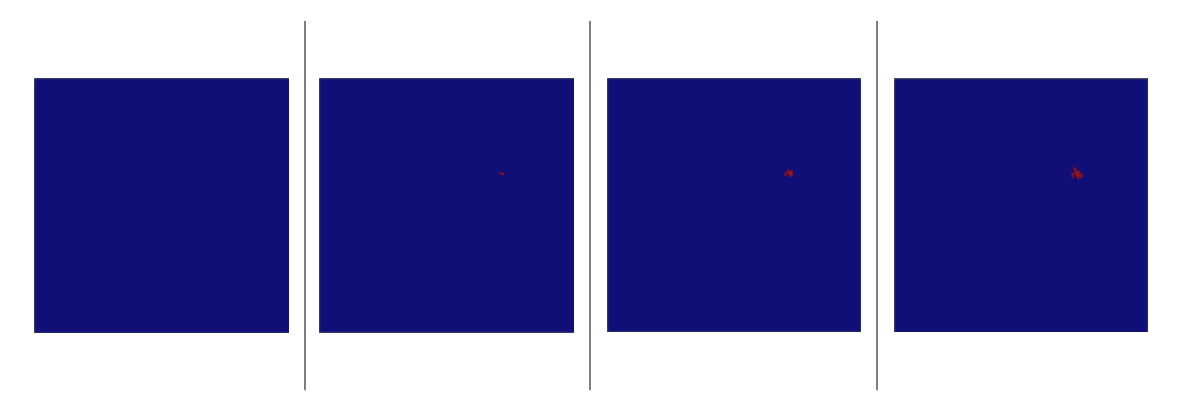